In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models,datasets



In [ ]:
(X_train,y_train),(X_test,y_test)=datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

In [7]:
model_CNN=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model_CNN.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model_CNN.fit(X_test,y_test,epochs=5)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8568 - loss: 0.8406
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9638 - loss: 0.1154
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9750 - loss: 0.0741
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9857 - loss: 0.0382
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9833 - loss: 0.0519


model_CNN.evaluate(X_test,y_test)

In [13]:
model_CNN.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9822 - loss: 0.0528


[0.05275033414363861, 0.982200026512146]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


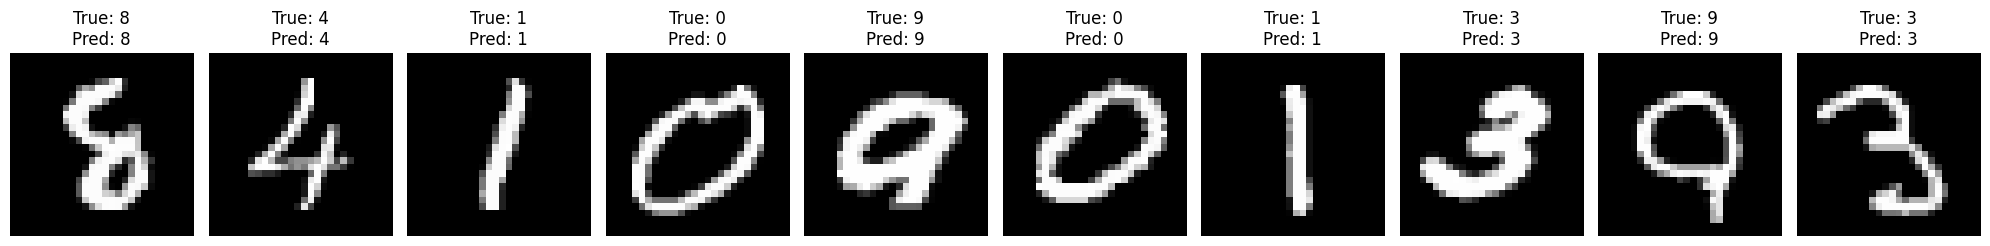

In [16]:
X_test_reshaped = X_test.reshape(X_test.shape[0], 28, 28, 1)

# Select a few random images from the test set
num_images = 10
random_indices = np.random.choice(X_test_reshaped.shape[0], num_images, replace=False)

plt.figure(figsize=(20, 10))
for i, idx in enumerate(random_indices):
    image = X_test_reshaped[idx]
    true_label = y_test[idx]

    # Make prediction
    predict = model_CNN.predict(np.expand_dims(image, axis=0))
    predicted_label = np.argmax(predict[0])

    plt.subplot(4, 10, i + 1)  # Create a 2x5 grid of subplots
    plt.imshow(image.squeeze(), cmap='gray') # Use squeeze to remove single-dimensional entries
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()